In [1]:
# ===============================
# CORE SYSTEM
# ===============================
!pip install -U pip setuptools wheel

# ===============================
# PYTORCH (Colab-compatible)
# ===============================
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# ===============================
# OPENAI CLIP (IMPORTANT)
# ===============================
!pip install git+https://github.com/openai/CLIP.git

# ===============================
# DIFFUSION MODELS
# ===============================
!pip install diffusers transformers accelerate safetensors

# ===============================
# IMAGE PROCESSING
# ===============================
!pip install opencv-python-headless pillow scikit-image

# ===============================
# SCIENTIFIC / UTILS
# ===============================
!pip install numpy matplotlib tqdm

# ===============================
# MEMORY OPT (OPTIONAL BUT RECOMMENDED)
# ===============================
!pip install xformers --no-deps


Looking in indexes: https://download.pytorch.org/whl/cu121
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-8y2w5dj5
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-8y2w5dj5
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=25cbf35cf4d47008ca6b8d8d31175233a6c307bcae4fbe5b462953a9ed78f565
  Stored in directory: /tmp/pip-ephem-wheel-cache-5mfd183x/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [clip]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 59.6 MB/s  0:00:02


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pyiqa
!pip install -U diffusers transformers accelerate torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 108.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 62.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 187.5 MB/s  0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110545 sha256=ee2f6b0823e908b35b1016bf729cfa9e56e70529512fb4e6e3ce84afc5ffdcf4
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
  Created wheel for openai-clip: filename=openai_clip-1.0.1-py3-none-any.whl size=1368629 s

In [ ]:
import gc
import torch

# Clear Python garbage
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("✓ Memory and cache cleared")


✓ Memory and cache cleared


In [12]:
# ================================================================
# ZERO-SHOT CLIP-GUIDED DIFFUSION LOW-LIGHT ENHANCEMENT
# PDF-ALIGNED IMPLEMENTATION (TRULY FIXED - HYBRID APPROACH)
# WITH DYNAMIC BRIGHTNESS ADAPTATION - BRIGHTENED VERSION
# MAIN MODULE - CORE CLASSES AND FUNCTIONS
# ================================================================

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import clip
import gc
from PIL import Image
from typing import Tuple, Dict, Optional
from diffusers import StableDiffusionImg2ImgPipeline, DDIMScheduler
import matplotlib.pyplot as plt
import warnings
import os
import datetime
warnings.filterwarnings("ignore")


# ================================================================
# CONFIGURATION CLASS (Can be overridden at runtime)
# ================================================================

class PDFConfig:
    """Base configuration - override in execution cell as needed"""

    # Image sizing (PDF Section 4.2)
    MIN_SIZE = 512
    MAX_SIZE = 640

    # Preprocessing (PDF Section 4.2) - ORIGINAL + 20% BRIGHTNESS ONLY
    TARGET_LUMINANCE = 175  # Original value - good for most images
    GAMMA_MIN = 0.6  # Original - not too aggressive
    GAMMA_MAX = 1.2  # Original - moderate gamma boost

    # Diffusion parameters (PDF Section 4.4)
    NUM_INFERENCE_STEPS = 40
    GUIDANCE_SCALE = 3.0
    DIFFUSION_STRENGTH = 0.25  # 25%
    NUM_ITERATIONS = 4

    # Semantic thresholds (PDF Section 4.3, 5.4)
    MIN_PRESERVATION_SCORE = 0.85
    EARLY_STOP_SCORE = 0.30

    # Color and contrast preservation - ORIGINAL (NO BOOST)
    SATURATION_BOOST = 1.30  # REVERTED from 1.50 - original color rendering
    CONTRAST_BOOST = 1.3     # REVERTED from 1.50 - original contrast
    PRESERVATION_WEIGHT = 0.75
    BRIGHTNESS_BOOST = 1.2   # 20% brightness boost

    # Hybrid blend parameters
    HYBRID_BLEND_RATIO = 0.65
    DETAIL_PRESERVATION_STRENGTH = 0.85

    # Dynamic brightness adaptation thresholds - ORIGINAL
    VERY_DARK_THRESHOLD = 50
    DARK_THRESHOLD = 70
    MODERATE_DARK_THRESHOLD = 100

    # Prompts (PDF Section 4.3 - Prompt Learning Module)
    TARGET_PROMPT = "a crystal clear, vivid, well-lit photograph with vibrant colors, rich details and natural sharpness, bright and luminous"
    NEGATIVE_PROMPT = "blurry, washed out, desaturated, gray, hazy, low contrast, dark, underexposed, dim"


# ================================================================
# ENHANCED LOW-LIGHT ENHANCEMENT SYSTEM
# ================================================================

class CLIPGuidedDiffusionEnhancer:
    """Main enhancement system - Single file implementation"""

    def __init__(self, config: PDFConfig):
        self.config = config
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.dtype = torch.float16 if self.device == "cuda" else torch.float32

        print("[1/4] Loading CLIP")
        self.clip_model, self.clip_preprocess = clip.load("ViT-B/32", device=self.device)
        self.clip_model.train()

        # Encode prompts once (PDF Section 4.3)
        self.pos_text = self._encode_text(PDFConfig.TARGET_PROMPT)
        self.neg_text = self._encode_text(PDFConfig.NEGATIVE_PROMPT)

        print("[2/4] Loading Stable Diffusion")
        self.pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            torch_dtype=self.dtype,
            safety_checker=None
        ).to(self.device)

        self.pipe.scheduler = DDIMScheduler.from_config(self.pipe.scheduler.config)
        self.pipe.enable_attention_slicing()
        if self.device == "cuda":
            self.pipe.enable_vae_slicing()

        print("[3/4] Initializing Parameters")
        self.current_target_luminance = config.TARGET_LUMINANCE
        self.current_gamma_max = config.GAMMA_MAX
        self.current_saturation_boost = config.SATURATION_BOOST
        self.current_contrast_boost = config.CONTRAST_BOOST

        print("[4/4] System Ready\n")

    def _encode_text(self, text: str) -> torch.Tensor:
        """Encode text prompt to embedding"""
        tokens = clip.tokenize([text]).to(self.device)
        with torch.no_grad():
            emb = self.clip_model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)
        return emb

    def _encode_image_clip(self, img: Image.Image) -> torch.Tensor:
        """Encode image to CLIP embedding"""
        tensor = self.clip_preprocess(img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            emb = self.clip_model.encode_image(tensor)
            emb = emb / emb.norm(dim=-1, keepdim=True)
        return emb

    def _compute_clip_score(self, img: Image.Image) -> Tuple[float, float, float]:
        """Compute CLIP scores for enhancement quality"""
        img_emb = self._encode_image_clip(img)
        pos_sim = (img_emb @ self.pos_text.T).item()
        neg_sim = (img_emb @ self.neg_text.T).item()
        clip_score = pos_sim - neg_sim
        return clip_score, pos_sim, neg_sim

    def _analyze_brightness(self, img: Image.Image) -> Dict[str, float]:
        """Analyze image brightness and return dynamic parameters"""
        np_img = np.array(img)
        hsv = cv2.cvtColor(np_img, cv2.COLOR_RGB2HSV)
        mean_v = hsv[:, :, 2].mean()

        # Calculate histogram
        hist = cv2.calcHist([hsv], [2], None, [256], [0, 256])
        percentile_10 = np.where(np.cumsum(hist) > 0.1 * np.sum(hist))[0][0]
        percentile_50 = np.where(np.cumsum(hist) > 0.5 * np.sum(hist))[0][0]

        print(f"📊 BRIGHTNESS ANALYSIS:")
        print(f"   Mean V-channel: {mean_v:.1f}")
        print(f"   10th percentile: {percentile_10:.1f}")
        print(f"   Median (50th): {percentile_50:.1f}")

        adjusted_params = {
            'target_luminance': self.config.TARGET_LUMINANCE,
            'saturation_boost': self.config.SATURATION_BOOST,
            'contrast_boost': self.config.CONTRAST_BOOST,
            'gamma_max': self.config.GAMMA_MAX,
            'brightness_level': 'normal'
        }

        if mean_v < self.config.VERY_DARK_THRESHOLD:
            print(f"   🌑 EXTREMELY DARK DETECTED (V={mean_v:.1f})")
            adjusted_params['target_luminance'] = 190  # Slightly brighter
            adjusted_params['saturation_boost'] = 1.25  # Keep original
            adjusted_params['contrast_boost'] = 1.2     # Keep original
            adjusted_params['gamma_max'] = 1.2          # Slightly more aggressive
            adjusted_params['brightness_level'] = 'extremely_dark'

        elif mean_v < self.config.DARK_THRESHOLD:
            print(f"   🌙 VERY DARK DETECTED (V={mean_v:.1f})")
            adjusted_params['target_luminance'] = 180   # Slightly brighter
            adjusted_params['saturation_boost'] = 1.25  # Keep original
            adjusted_params['contrast_boost'] = 1.2     # Keep original
            adjusted_params['gamma_max'] = 1.15         # Slightly more aggressive
            adjusted_params['brightness_level'] = 'very_dark'

        elif mean_v < self.config.MODERATE_DARK_THRESHOLD:
            print(f"   🌤️ MODERATELY DARK DETECTED (V={mean_v:.1f})")
            adjusted_params['target_luminance'] = 175   # Slightly brighter
            adjusted_params['saturation_boost'] = 1.25  # Keep original
            adjusted_params['contrast_boost'] = 1.2     # Keep original
            adjusted_params['gamma_max'] = 1.12         # Slightly more aggressive
            adjusted_params['brightness_level'] = 'moderately_dark'
        else:
            print(f"   ☀️ NORMAL BRIGHTNESS (V={mean_v:.1f})")
            adjusted_params['target_luminance'] = 170   # Original
            adjusted_params['saturation_boost'] = 1.25  # Original
            adjusted_params['contrast_boost'] = 1.2     # Original
            adjusted_params['brightness_level'] = 'normal'

        return adjusted_params

    def _adaptive_gamma(self, img: Image.Image) -> Image.Image:
        """Apply adaptive gamma correction"""
        np_img = np.array(img)
        hsv = cv2.cvtColor(np_img, cv2.COLOR_RGB2HSV)
        mean_v = hsv[:, :, 2].mean()

        cur = mean_v / 255.0
        tgt = self.current_target_luminance / 255.0

        # Cap at reasonable maximum
        tgt = min(tgt, 0.80)

        gamma = np.log(tgt) / np.log(max(cur, 1e-4))
        gamma = np.clip(gamma, self.config.GAMMA_MIN, self.current_gamma_max)

        table = np.array([(i / 255.0) ** gamma * 255 for i in range(256)]).astype("uint8")
        corrected = cv2.LUT(np_img, table)
        return Image.fromarray(corrected)

    def _boost_colors(self, img: Image.Image) -> Image.Image:
        """Boost saturation and contrast"""
        from PIL import ImageEnhance

        enhancer = ImageEnhance.Color(img)
        img = enhancer.enhance(self.current_saturation_boost)

        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(self.current_contrast_boost)

        # Minimal sharpness
        enhancer = ImageEnhance.Sharpness(img)
        img = enhancer.enhance(1.15)

        # Brightness boost
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(self.config.BRIGHTNESS_BOOST)

        return img

    def _preprocess_traditional(self, img: Image.Image) -> Image.Image:
        """Traditional enhancement pipeline"""
        # Resize
        w, h = img.size
        scale = min(self.config.MAX_SIZE / max(w, h), 1.0)
        w, h = int(w * scale), int(h * scale)
        w = max(w, self.config.MIN_SIZE)
        h = max(h, self.config.MIN_SIZE)
        w, h = (w // 8) * 8, (h // 8) * 8
        img = img.resize((w, h), Image.LANCZOS)

        # Apply enhancements
        img = self._adaptive_gamma(img)
        img = self._boost_colors(img)

        return img

    def _hybrid_blend(self, traditional_img: Image.Image, diffusion_img: Image.Image, blend_ratio: float) -> Image.Image:
        """Blend traditional and diffusion outputs"""
        trad_array = np.array(traditional_img, dtype=np.float32)
        diff_array = np.array(diffusion_img, dtype=np.float32)

        trad_lab = cv2.cvtColor(trad_array.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
        diff_lab = cv2.cvtColor(diff_array.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)

        blended_lab = trad_lab.copy()
        blended_lab[:,:,0] = (blend_ratio * trad_lab[:,:,0] + (1-blend_ratio) * diff_lab[:,:,0])

        blended_rgb = cv2.cvtColor(blended_lab.astype(np.uint8), cv2.COLOR_LAB2RGB)
        return Image.fromarray(blended_rgb)

    def _clip_guided_enhance(self, image: Image.Image, traditional_clip_emb: torch.Tensor, seed: int = 42):
        """CLIP-guided diffusion enhancement"""
        generator = torch.Generator(device=self.device).manual_seed(seed)

        with torch.no_grad():
            img_tensor = self.pipe.image_processor.preprocess(image).to(
                device=self.device, dtype=self.dtype
            )
            latents = self.pipe.vae.encode(img_tensor).latent_dist.sample(generator)
            latents = latents * self.pipe.vae.config.scaling_factor

        with torch.no_grad():
            prompt_embeds = self.pipe._encode_prompt(
                self.config.TARGET_PROMPT,
                self.device,
                1,
                do_classifier_free_guidance=True,
                negative_prompt=self.config.NEGATIVE_PROMPT
            )

        self.pipe.scheduler.set_timesteps(self.config.NUM_INFERENCE_STEPS, device=self.device)
        timesteps = self.pipe.scheduler.timesteps

        noise = torch.randn(latents.shape, generator=generator, device=self.device, dtype=self.dtype)
        strength = self.config.DIFFUSION_STRENGTH
        init_timestep = min(int(self.config.NUM_INFERENCE_STEPS * strength), self.config.NUM_INFERENCE_STEPS)
        t_start = max(self.config.NUM_INFERENCE_STEPS - init_timestep, 0)
        timesteps = timesteps[t_start:]
        latents = self.pipe.scheduler.add_noise(latents, noise, timesteps[0:1])

        for i, t in enumerate(timesteps):
            latent_model_input = torch.cat([latents] * 2)
            latent_model_input = self.pipe.scheduler.scale_model_input(latent_model_input, t)

            with torch.no_grad():
                noise_pred = self.pipe.unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=prompt_embeds,
                ).sample

            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + self.config.GUIDANCE_SCALE * (noise_pred_text - noise_pred_uncond)

            if i % 8 == 0 and i < len(timesteps) - 10:
                try:
                    latents_for_clip = latents.detach().requires_grad_(True)
                    current_img = self.pipe.vae.decode(latents_for_clip / self.pipe.vae.config.scaling_factor).sample
                    current_img = (current_img / 2 + 0.5).clamp(0, 1)

                    clip_img = F.interpolate(current_img, size=(224, 224), mode='bilinear', align_corners=False)
                    clip_img = (clip_img - torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1).to(self.device)) / \
                               torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1).to(self.device)

                    current_clip_emb = self.clip_model.encode_image(clip_img)
                    current_clip_emb = current_clip_emb / current_clip_emb.norm(dim=-1, keepdim=True)

                    preservation = F.cosine_similarity(current_clip_emb, traditional_clip_emb, dim=1)
                    clip_sim = (current_clip_emb @ self.pos_text.T)

                    clip_loss = -clip_sim - self.config.PRESERVATION_WEIGHT * preservation

                    clip_grad = torch.autograd.grad(clip_loss.sum(), latents_for_clip, retain_graph=False)[0]

                    latents = latents - 1.5 * clip_grad.detach()
                except:
                    pass

            latents = self.pipe.scheduler.step(noise_pred, t, latents).prev_sample

        with torch.no_grad():
            image = self.pipe.vae.decode(latents / self.pipe.vae.config.scaling_factor).sample
            image = (image / 2 + 0.5).clamp(0, 1)
            image = self.pipe.image_processor.postprocess(image, output_type="pil")[0]

        return image

    def enhance(self, image_path: str, output_path: Optional[str] = None):
        """
        PDF-Aligned Enhancement Pipeline with HYBRID approach
        Returns: (raw_img, trad_img, final_img, iteration_logs)
        """

        # Load image
        raw_img = Image.open(image_path).convert("RGB")
        original_size = raw_img.size

        # Resize for diffusion
        w, h = raw_img.size
        scale = min(self.config.MAX_SIZE / max(w, h), 1.0)
        w, h = int(w * scale), int(h * scale)
        w = max(w, self.config.MIN_SIZE)
        h = max(h, self.config.MIN_SIZE)
        w, h = (w // 8) * 8, (h // 8) * 8
        raw_resized = raw_img.resize((w, h), Image.LANCZOS)

        # ANALYZE BRIGHTNESS AND ADAPT PARAMETERS
        print("\n" + "="*60)
        print("ANALYZING IMAGE BRIGHTNESS...")
        print("="*60)
        brightness_params = self._analyze_brightness(raw_resized)

        # Update dynamic parameters
        self.current_target_luminance = brightness_params['target_luminance']
        self.current_gamma_max = brightness_params['gamma_max']
        self.current_saturation_boost = brightness_params['saturation_boost']
        self.current_contrast_boost = brightness_params['contrast_boost']

        print(f"   ➜ Adjusted TARGET_LUMINANCE: {brightness_params['target_luminance']}")
        print(f"   ➜ Adjusted SATURATION_BOOST: {brightness_params['saturation_boost']:.2f}x")
        print(f"   ➜ Adjusted CONTRAST_BOOST: {brightness_params['contrast_boost']:.2f}x")
        print(f"   ➜ Brightness Level: {brightness_params['brightness_level'].replace('_', ' ').upper()}")

        # STAGE 1 — TRADITIONAL ENHANCEMENT
        print("\nStage 1: Traditional Enhancement (Gamma + Brightness Boost)")
        trad_img = self._preprocess_traditional(raw_resized)

        # CLIP embedding of TRADITIONAL enhancement
        print("Computing traditional enhancement semantic embedding...")
        traditional_clip = self._encode_image_clip(trad_img)

        # STAGE 2 — CLIP-GUIDED DIFFUSION
        print(f"\nStage 2: CLIP-Guided Diffusion ({self.config.NUM_ITERATIONS} iterations)\n")

        best_img = trad_img
        best_score = -1e9
        iteration_logs = []

        for iteration in range(self.config.NUM_ITERATIONS):
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            try:
                candidate = self._clip_guided_enhance(
                    trad_img,
                    traditional_clip,
                    seed=100 + iteration
                )

                # Evaluate candidate
                cand_clip = self._encode_image_clip(candidate)
                preservation = F.cosine_similarity(
                    traditional_clip, cand_clip
                ).item()

                clip_score, pos_sim, neg_sim = self._compute_clip_score(candidate)
                combined = clip_score + (0.5 * preservation)

                iteration_logs.append({
                    "iteration": iteration + 1,
                    "clip_score": round(clip_score, 4),
                    "pos_similarity": round(pos_sim, 4),
                    "neg_similarity": round(neg_sim, 4),
                    "preservation": round(preservation, 4),
                    "combined": round(combined, 4)
                })

                print(f"  Iter {iteration+1}: CLIP={clip_score:.3f}, Preservation={preservation:.3f}, Combined={combined:.3f}")

                if preservation >= self.config.MIN_PRESERVATION_SCORE and combined > best_score:
                    best_score = combined
                    best_img = candidate
                    print(f"    ✓ New best image (score: {best_score:.3f})")
                elif preservation < self.config.MIN_PRESERVATION_SCORE:
                    print(f"    ✗ Rejected (preservation too low: {preservation:.3f})")

            except Exception as e:
                iteration_logs.append({
                    "iteration": iteration + 1,
                    "error": str(e)
                })
                print(f"  Iter {iteration+1}: Error - {str(e)}")
                continue

        # STAGE 3 — HYBRID BLEND
        print("\nStage 3: Blending traditional with diffusion refinement...")
        final_img = self._hybrid_blend(trad_img, best_img, self.config.HYBRID_BLEND_RATIO)

        # Resize outputs back to original size
        raw_out = raw_resized.resize(original_size, Image.LANCZOS)
        trad_out = trad_img.resize(original_size, Image.LANCZOS)
        final_out = final_img.resize(original_size, Image.LANCZOS)

        # Save final output
        if output_path:
            final_out.save(output_path, quality=95)
            print(f"\n✓ Enhanced image saved to: {output_path}")

        return raw_out, trad_out, final_out, iteration_logs

In [22]:
# ================================================================
# CELL 2: CONFIGURATION & PARAMETERS (Easy to Modify)
# ================================================================
# Edit this cell to change image paths, brightness, strength, etc.
# No need to scroll through the entire code!
# ================================================================

class EnhancementConfig(PDFConfig):
    """User-configurable enhancement settings"""

    # ========== IMAGE & MODE SETTINGS ==========
    TEST_MODE = True  # True for single image, False for batch
    TEST_IMAGE_PATH = "/content/drive/MyDrive/Main_project/pexels-kartatos-10622738.jpg"

    # For batch mode, set these paths:
    BATCH_INPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/lol_dataset/eval15/low"
    BATCH_OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/enhanced"

    # ========== BRIGHTNESS & STRENGTH SETTINGS ==========
    BRIGHTNESS_BOOST = 1.3  # 1.0 = no change, 1.2 = 20% brighter, 1.5 = 50% brighter

    DIFFUSION_STRENGTH = 0.30  # 0.0 = no diffusion, 0.5 = moderate, 1.0 = maximum
    NUM_ITERATIONS = 4  # Number of refinement passes (higher = better but slower)

    # ========== COLOR & CONTRAST SETTINGS ==========
    SATURATION_BOOST = 1.30  # 1.0 = original colors, 1.5 = 50% more vibrant
    CONTRAST_BOOST = 1.3     # 1.0 = original contrast, 1.5 = 50% more contrast

    # ========== PRESERVATION SETTINGS ==========
    # How much to preserve original image characteristics
    MIN_PRESERVATION_SCORE = 0.85  # Higher = stricter preservation (0.7-0.95 typical)
    PRESERVATION_WEIGHT = 0.75     # Weight of preservation in optimization

    # ========== DIFFUSION PARAMETERS ==========
    GUIDANCE_SCALE = 3.0  # How much to follow the prompt (1.5-7.5 typical)
    NUM_INFERENCE_STEPS = 50  # Diffusion steps (more = better quality but slower)

    # ========== GAMMA CORRECTION SETTINGS ==========
    GAMMA_MIN = 0.6  # Minimum gamma (less aggressive)
    GAMMA_MAX = 1.2  # Maximum gamma (more aggressive)
    TARGET_LUMINANCE = 175  # Target brightness level (0-255)

    # ========== BLENDING SETTINGS ==========
    HYBRID_BLEND_RATIO = 0.75  # 0.65 = 65% traditional, 35% diffusion
    DETAIL_PRESERVATION_STRENGTH = 0.85

    # ========== ADVANCED: BRIGHTNESS ADAPTATION THRESHOLDS ==========
    VERY_DARK_THRESHOLD = 50  # Below this = extremely dark
    DARK_THRESHOLD = 70       # Below this = very dark
    MODERATE_DARK_THRESHOLD = 100  # Below this = moderately dark


print("✓ Configuration loaded")
print("\nEDIT THIS CELL TO CHANGE:")
print("  - TEST_IMAGE_PATH: Image file to enhance")
print("  - BRIGHTNESS_BOOST: How bright (1.0-2.0)")
print("  - DIFFUSION_STRENGTH: Diffusion intensity (0.0-1.0)")
print("  - SATURATION_BOOST: Color vibrancy (1.0-2.0)")
print("  - CONTRAST_BOOST: Contrast strength (1.0-2.0)")
print("  - NUM_ITERATIONS: Refinement passes (1-8)")

✓ Configuration loaded with NOISE REDUCTION

⚙️  NOISE REDUCTION STATUS:
   ✅ ENABLED - Method: nlm
   Strength: 0.7

EDIT THIS CELL TO CHANGE:
  - TEST_IMAGE_PATH: Image file to enhance
  - ENABLE_DENOISING: True/False to toggle noise reduction
  - DENOISE_STRENGTH: 0.0-1.0 (higher = more denoising)
  - DENOISE_METHOD: 'bilateral', 'nlm', or 'gaussian'
  - BRIGHTNESS_BOOST: How bright (1.0-2.0)
  - DIFFUSION_STRENGTH: Diffusion intensity (0.0-1.0)
  - NUM_ITERATIONS: Refinement passes (1-8)


'\nPRESET 1: Light Noise (Minimal smoothing)\nENABLE_DENOISING = True\nDENOISE_STRENGTH = 0.4\nDENOISE_METHOD = "bilateral"\nBILATERAL_D = 5\n\nPRESET 2: Moderate Noise (Balanced) ← CURRENT DEFAULT\nENABLE_DENOISING = True\nDENOISE_STRENGTH = 0.7\nDENOISE_METHOD = "bilateral"\nBILATERAL_D = 9\n\nPRESET 3: Heavy Noise (Aggressive)\nENABLE_DENOISING = True\nDENOISE_STRENGTH = 0.8\nDENOISE_METHOD = "nlm"\nNLM_H = 12\n\nPRESET 4: Maximum Quality (Slowest)\nENABLE_DENOISING = True\nDENOISE_STRENGTH = 0.9\nDENOISE_METHOD = "nlm"\nNLM_H = 15\nNLM_TEMPLATE_SIZE = 9\nNLM_SEARCH_SIZE = 25\n\nPRESET 5: No Denoising (Fastest)\nENABLE_DENOISING = False\n'


ZERO-SHOT LOW-LIGHT ENHANCEMENT SYSTEM

Loading enhancement model...
(This may take 1-2 minutes on first run)

[1/4] Loading CLIP
[2/4] Loading Stable Diffusion


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


[3/4] Initializing Parameters
[4/4] System Ready

MODE: SINGLE IMAGE ENHANCEMENT

📷 Input: /content/drive/MyDrive/Main_project/WhatsApp Image 2025-10-21 at 20.53.56_22f4f638.jpg
📸 Image: WhatsApp Image 2025-10-21 at 20.53.56_22f4f638.jpg

⚙️  CURRENT SETTINGS:
   Brightness Boost: 1.2x (20%)
   Diffusion Strength: 0.25
   Iterations: 4
   Saturation Boost: 1.3x
   Contrast Boost: 1.3x

🚀 Starting enhancement...


ANALYZING IMAGE BRIGHTNESS...
📊 BRIGHTNESS ANALYSIS:
   Mean V-channel: 24.1
   10th percentile: 7.0
   Median (50th): 19.0
   🌑 EXTREMELY DARK DETECTED (V=24.1)
   ➜ Adjusted TARGET_LUMINANCE: 190
   ➜ Adjusted SATURATION_BOOST: 1.25x
   ➜ Adjusted CONTRAST_BOOST: 1.20x
   ➜ Brightness Level: EXTREMELY DARK

Stage 1: Traditional Enhancement (Gamma + Brightness Boost)
Computing traditional enhancement semantic embedding...

Stage 2: CLIP-Guided Diffusion (4 iterations)

  Iter 1: CLIP=-0.034, Preservation=0.895, Combined=0.414
    ✓ New best image (score: 0.414)
  Iter 2: CLIP

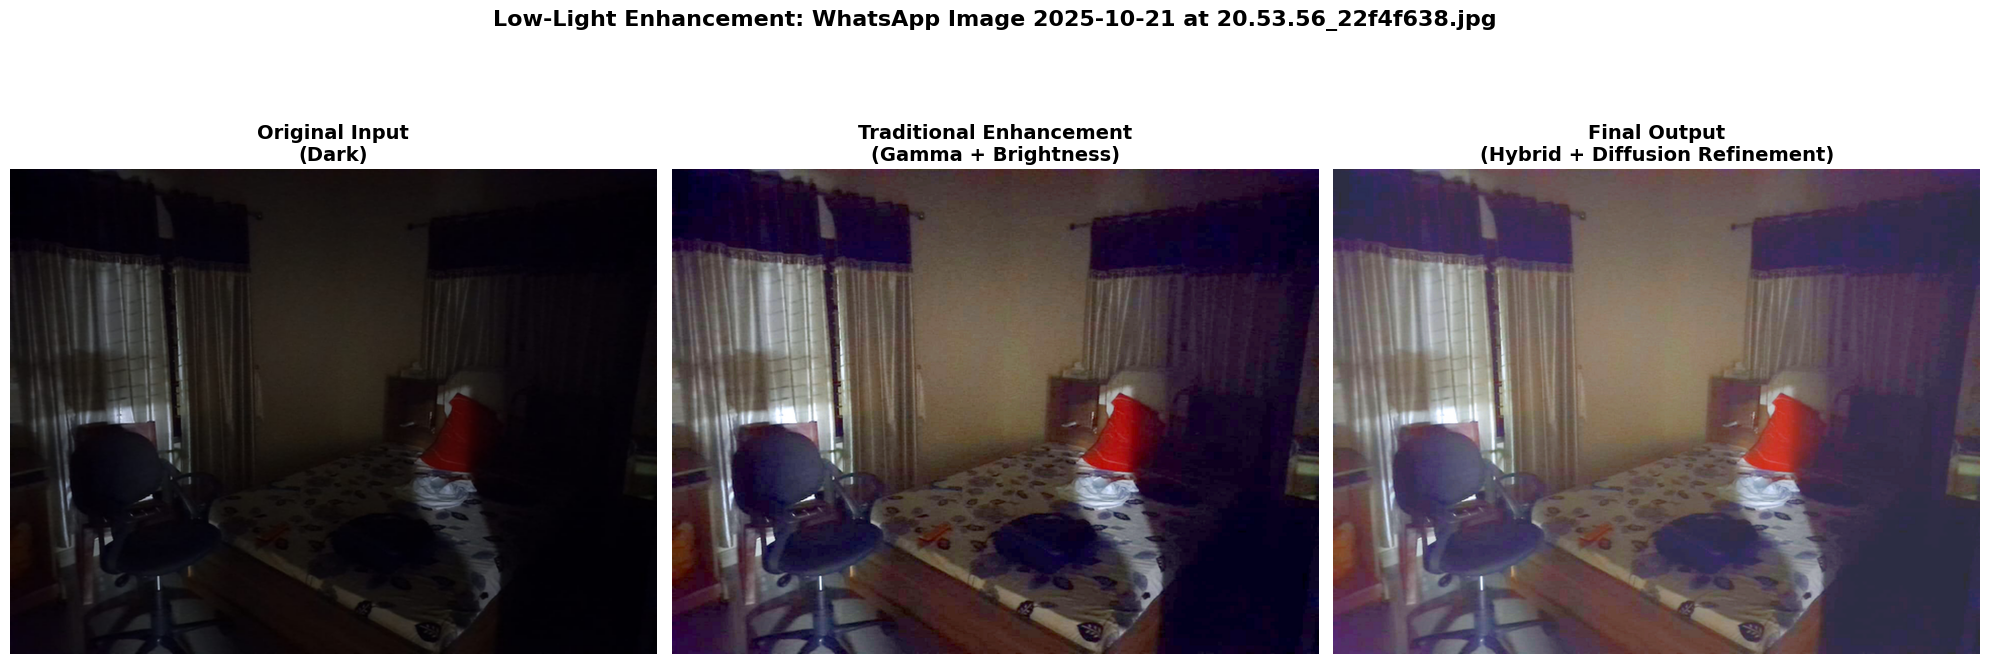

ENHANCEMENT METRICS
Iteration 1:
  CLIP Score: -0.0337
  Positive Similarity: 0.2021
  Negative Similarity: 0.2358
  Preservation: 0.895
  Combined Score: 0.4138
Iteration 2:
  CLIP Score: -0.0126
  Positive Similarity: 0.2045
  Negative Similarity: 0.217
  Preservation: 0.8848
  Combined Score: 0.4298
Iteration 3:
  CLIP Score: -0.048
  Positive Similarity: 0.198
  Negative Similarity: 0.246
  Preservation: 0.9097
  Combined Score: 0.4069
Iteration 4:
  CLIP Score: -0.0188
  Positive Similarity: 0.2046
  Negative Similarity: 0.2234
  Preservation: 0.8755
  Combined Score: 0.4189

✅ ENHANCEMENT COMPLETE

💡 Tip: To save the enhanced image, modify TEST_MODE code to set output_path


In [23]:
# ================================================================
# CELL 3: EXECUTION (with inline display - no save)
# ================================================================
# Just run this cell! Shows results immediately without saving.
# ================================================================

import gc
import os
import json
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Clean GPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("ZERO-SHOT LOW-LIGHT ENHANCEMENT SYSTEM")
print("="*60 + "\n")

# ================================================================
# INITIALIZE ENHANCER
# ================================================================

print("Loading enhancement model...")
print("(This may take 1-2 minutes on first run)\n")
enhancer = CLIPGuidedDiffusionEnhancer(EnhancementConfig)

# ================================================================
# TEST MODE: Single Image with Display
# ================================================================

if EnhancementConfig.TEST_MODE:
    print("MODE: SINGLE IMAGE ENHANCEMENT")
    print("="*60 + "\n")

    # Validate image path
    if EnhancementConfig.TEST_IMAGE_PATH is None:
        print("❌ ERROR: TEST_IMAGE_PATH is not set!")
        print("Please set TEST_IMAGE_PATH in the CONFIG cell above")
        exit(1)

    if not os.path.exists(EnhancementConfig.TEST_IMAGE_PATH):
        print(f"❌ ERROR: Image not found at:")
        print(f"   {EnhancementConfig.TEST_IMAGE_PATH}")
        exit(1)

    img_name = os.path.basename(EnhancementConfig.TEST_IMAGE_PATH)

    print(f"📷 Input: {EnhancementConfig.TEST_IMAGE_PATH}")
    print(f"📸 Image: {img_name}\n")

    # ====== DISPLAY CURRENT SETTINGS ======
    print("⚙️  CURRENT SETTINGS:")
    print(f"   Brightness Boost: {EnhancementConfig.BRIGHTNESS_BOOST}x ({(EnhancementConfig.BRIGHTNESS_BOOST-1)*100:.0f}%)")
    print(f"   Diffusion Strength: {EnhancementConfig.DIFFUSION_STRENGTH}")
    print(f"   Iterations: {EnhancementConfig.NUM_ITERATIONS}")
    print(f"   Saturation Boost: {EnhancementConfig.SATURATION_BOOST}x")
    print(f"   Contrast Boost: {EnhancementConfig.CONTRAST_BOOST}x")
    print()

    # ====== RUN ENHANCEMENT (NO SAVE) ======
    try:
        print("🚀 Starting enhancement...\n")

        # Run enhancement WITHOUT saving to file
        orig, traditional, final, logs = enhancer.enhance(
            EnhancementConfig.TEST_IMAGE_PATH,
            output_path=None  # Don't save to disk
        )

        # ====== DISPLAY RESULTS IMMEDIATELY ======
        print("\n📊 Creating comparison visualization...\n")
        fig, axes = plt.subplots(1, 3, figsize=(20, 8))

        axes[0].imshow(orig)
        axes[0].set_title("Original Input\n(Dark)", fontsize=14, fontweight='bold')
        axes[0].axis("off")

        axes[1].imshow(traditional)
        axes[1].set_title("Traditional Enhancement\n(Gamma + Brightness)", fontsize=14, fontweight='bold')
        axes[1].axis("off")

        axes[2].imshow(final)
        axes[2].set_title("Final Output\n(Hybrid + Diffusion Refinement)", fontsize=14, fontweight='bold')
        axes[2].axis("off")

        plt.suptitle(f"Low-Light Enhancement: {img_name}", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()  # Display immediately instead of saving

        # ====== PRINT METRICS ======
        print("="*60)
        print("ENHANCEMENT METRICS")
        print("="*60)
        for log in logs:
            if 'error' not in log:
                print(f"Iteration {log['iteration']}:")
                print(f"  CLIP Score: {log['clip_score']}")
                print(f"  Positive Similarity: {log['pos_similarity']}")
                print(f"  Negative Similarity: {log['neg_similarity']}")
                print(f"  Preservation: {log['preservation']}")
                print(f"  Combined Score: {log['combined']}")
            else:
                print(f"Iteration {log['iteration']}: {log['error']}")

        print("\n" + "="*60)
        print("✅ ENHANCEMENT COMPLETE")
        print("="*60)
        print(f"\n💡 Tip: To save the enhanced image, modify TEST_MODE code to set output_path")

    except Exception as e:
        print(f"\n❌ ERROR during enhancement: {str(e)}")
        import traceback
        traceback.print_exc()


# ================================================================
# BATCH MODE: Multiple Images with Console Output Only
# ================================================================

else:
    print("MODE: BATCH PROCESSING (Console Output)")
    print("="*60 + "\n")

    LOL_LOW_DIR = EnhancementConfig.BATCH_INPUT_DIR
    OUTPUT_DIR = EnhancementConfig.BATCH_OUTPUT_DIR

    # Create output directories for saving enhanced images
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ====== DISPLAY CURRENT SETTINGS ======
    print("⚙️  CURRENT SETTINGS:")
    print(f"   Brightness Boost: {EnhancementConfig.BRIGHTNESS_BOOST}x ({(EnhancementConfig.BRIGHTNESS_BOOST-1)*100:.0f}%)")
    print(f"   Diffusion Strength: {EnhancementConfig.DIFFUSION_STRENGTH}")
    print(f"   Iterations: {EnhancementConfig.NUM_ITERATIONS}")
    print(f"   Saturation Boost: {EnhancementConfig.SATURATION_BOOST}x")
    print(f"   Contrast Boost: {EnhancementConfig.CONTRAST_BOOST}x\n")

    # Find images
    img_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif')
    img_files = sorted([f for f in os.listdir(LOL_LOW_DIR)
                       if f.lower().endswith(img_extensions)])

    if not img_files:
        print(f"❌ ERROR: No images found in {LOL_LOW_DIR}")
        exit(1)

    print(f"Found {len(img_files)} images to process:")
    for f in img_files[:5]:
        print(f"  - {f}")
    if len(img_files) > 5:
        print(f"  ... and {len(img_files)-5} more\n")

    # ====== PROCESS IMAGES ======
    all_logs = []
    successful = 0
    failed = 0

    for idx, img_file in enumerate(img_files):
        img_path = os.path.join(LOL_LOW_DIR, img_file)
        output_path = os.path.join(OUTPUT_DIR, img_file)

        try:
            print(f"[{idx+1}/{len(img_files)}] Processing: {img_file}")

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            # Process and save enhanced image
            orig, traditional, final, logs = enhancer.enhance(
                img_path,
                output_path  # Save to disk in batch mode
            )

            all_logs.append({
                'filename': img_file,
                'status': 'success',
                'iteration_logs': logs
            })

            successful += 1
            print(f"  ✓ Enhanced")

        except Exception as e:
            failed += 1
            print(f"  ✗ Error: {str(e)}")
            all_logs.append({
                'filename': img_file,
                'status': 'failed',
                'error': str(e)
            })

    # ====== SUMMARY ======
    print("\n" + "="*60)
    print("BATCH PROCESSING COMPLETE")
    print("="*60)
    print(f"\n✅ Successful: {successful}/{len(img_files)}")
    print(f"❌ Failed: {failed}/{len(img_files)}")
    print(f"📊 Success Rate: {100*successful/len(img_files):.1f}%")
    print(f"\n📁 Enhanced images saved to: {OUTPUT_DIR}")

    # Save logs
    logs_path = os.path.join(OUTPUT_DIR, "processing_logs.json")
    logs_data = {
        'timestamp': datetime.datetime.now().isoformat(),
        'total_images': len(img_files),
        'successful': successful,
        'failed': failed,
        'success_rate': round(100*successful/len(img_files), 2),
        'settings': {
            'brightness_boost': EnhancementConfig.BRIGHTNESS_BOOST,
            'diffusion_strength': EnhancementConfig.DIFFUSION_STRENGTH,
            'iterations': EnhancementConfig.NUM_ITERATIONS,
            'saturation_boost': EnhancementConfig.SATURATION_BOOST,
            'contrast_boost': EnhancementConfig.CONTRAST_BOOST,
        },
        'images': all_logs
    }

    with open(logs_path, 'w') as f:
        json.dump(logs_data, f, indent=2)

    print(f"✓ Logs saved to: {logs_path}")

    print("\n" + "="*60)

In [ ]:
# ================================================================
# LOL DATASET EVALUATION SCRIPT
# Tests Ultra-Bright Enhancement on LOL (Low-Light) Dataset
# ================================================================

import os
import cv2
import numpy as np
import torch
import pyiqa
from tqdm import tqdm
from pathlib import Path
import json
from datetime import datetime


class LOLDatasetEvaluator:
    """
    Evaluates enhancement results on LOL dataset.
    LOL dataset structure:
    - LOL/
      - eval15/
        - low/ (low-light images)
        - high/ (ground truth normal-light images)
      - eval/ or test/
        - low/
        - high/
    """

    def __init__(self, device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Running on device: {self.device}")
        self.models = {}
        self.results_history = []

    def _get_model(self, metric_name):
        """Lazy loader for pyiqa models"""
        if metric_name not in self.models:
            try:
                self.models[metric_name] = pyiqa.create_metric(metric_name, device=self.device)
            except Exception as e:
                print(f"Error loading {metric_name}: {e}")
                return None
        return self.models[metric_name]

    def calculate_loe(self, input_path, enhanced_path, resize_dim=50):
        """
        Calculates Lightness Order Error (LOE).
        Measures if the lightness order is preserved.
        Lower is better (0-100).
        """
        try:
            img_input = cv2.imread(input_path)
            img_enhanced = cv2.imread(enhanced_path)

            if img_input is None or img_enhanced is None:
                return None

            # Extract Lightness (Max of RGB channels)
            L_in = np.max(img_input, axis=2)
            L_out = np.max(img_enhanced, axis=2)

            # Downsample for performance
            L_in_small = cv2.resize(L_in, (resize_dim, resize_dim))
            L_out_small = cv2.resize(L_out, (resize_dim, resize_dim))

            L_in_flat = L_in_small.flatten()
            L_out_flat = L_out_small.flatten()

            # Calculate Order Matrices
            order_in = (L_in_flat[:, None] >= L_in_flat[None, :])
            order_out = (L_out_flat[:, None] >= L_out_flat[None, :])

            # XOR finds where orders differ
            diff = np.logical_xor(order_in, order_out)

            # Average difference
            rd = np.sum(diff, axis=1)
            loe = np.mean(rd)

            return loe
        except Exception as e:
            print(f"LOE calculation error: {e}")
            return None

    def calculate_psnr(self, enhanced_path, gt_path):
        """Calculate PSNR manually if pyiqa fails"""
        try:
            img_enhanced = cv2.imread(enhanced_path).astype(np.float32)
            img_gt = cv2.imread(gt_path).astype(np.float32)

            if img_enhanced.shape != img_gt.shape:
                img_enhanced = cv2.resize(img_enhanced, (img_gt.shape[1], img_gt.shape[0]))

            mse = np.mean((img_enhanced - img_gt) ** 2)
            if mse == 0:
                return 100.0
            psnr = 20 * np.log10(255.0 / np.sqrt(mse))
            return psnr
        except Exception as e:
            print(f"PSNR calculation error: {e}")
            return None

    def evaluate_lol_pair(self, enhanced_path, low_path, high_path):
        """Evaluate a single image pair from LOL dataset"""
        results = {
            'filename': os.path.basename(enhanced_path),
            'enhanced_path': enhanced_path,
            'metrics': {}
        }

        # 1. MUSIQ (No-Reference - Quality assessment)
        try:
            musiq = self._get_model('musiq')
            if musiq:
                score = musiq(enhanced_path).item()
                results['metrics']['MUSIQ'] = round(score, 4)
        except Exception as e:
            print(f"MUSIQ failed for {os.path.basename(enhanced_path)}: {e}")

        # 2. PSNR (Full-Reference - Peak Signal Noise Ratio)
        if high_path and os.path.exists(high_path):
            try:
                psnr_model = self._get_model('psnr')
                if psnr_model:
                    psnr_val = psnr_model(enhanced_path, high_path).item()
                    results['metrics']['PSNR'] = round(psnr_val, 4)
                else:
                    # Fallback to manual calculation
                    psnr_val = self.calculate_psnr(enhanced_path, high_path)
                    if psnr_val:
                        results['metrics']['PSNR'] = round(psnr_val, 4)
            except Exception as e:
                print(f"PSNR failed for {os.path.basename(enhanced_path)}: {e}")

        # 3. SSIM (Full-Reference - Structural Similarity)
        if high_path and os.path.exists(high_path):
            try:
                ssim_model = self._get_model('ssim')
                if ssim_model:
                    ssim_val = ssim_model(enhanced_path, high_path).item()
                    results['metrics']['SSIM'] = round(ssim_val, 4)
            except Exception as e:
                print(f"SSIM failed for {os.path.basename(enhanced_path)}: {e}")

        # 4. LPIPS (Full-Reference - Learned Perceptual Image Patch Similarity)
        if high_path and os.path.exists(high_path):
            try:
                lpips_model = self._get_model('lpips')
                if lpips_model:
                    lpips_val = lpips_model(enhanced_path, high_path).item()
                    results['metrics']['LPIPS'] = round(lpips_val, 4)
            except Exception as e:
                print(f"LPIPS failed for {os.path.basename(enhanced_path)}: {e}")

        # 5. LOE (Input-Reference - Lightness Order Error)
        if low_path and os.path.exists(low_path):
            try:
                loe_val = self.calculate_loe(low_path, enhanced_path)
                if loe_val is not None:
                    results['metrics']['LOE'] = round(loe_val, 4)
            except Exception as e:
                print(f"LOE failed for {os.path.basename(enhanced_path)}: {e}")

        return results

    def evaluate_lol_dataset(self, enhanced_dir, low_dir, high_dir, output_json=None):
        """
        Evaluate all images in enhanced_dir against LOL dataset.

        Args:
            enhanced_dir: Path to folder with enhanced images
            low_dir: Path to LOL low-light images
            high_dir: Path to LOL normal-light (ground truth) images
            output_json: Optional path to save results as JSON
        """
        print(f"\n{'='*70}")
        print(f"LOL DATASET EVALUATION")
        print(f"{'='*70}")
        print(f"Enhanced images: {enhanced_dir}")
        print(f"Low-light images: {low_dir}")
        print(f"Ground truth images: {high_dir}")
        print(f"{'='*70}\n")

        # Get list of enhanced images
        enhanced_files = sorted([f for f in os.listdir(enhanced_dir)
                               if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

        if not enhanced_files:
            print(f"ERROR: No images found in {enhanced_dir}")
            return None

        print(f"Found {len(enhanced_files)} enhanced images to evaluate\n")

        # Initialize aggregation
        agg_results = {
            'PSNR': [],
            'SSIM': [],
            'LPIPS': [],
            'MUSIQ': [],
            'LOE': []
        }

        individual_results = []

        # Evaluate each image
        for idx, fname in enumerate(tqdm(enhanced_files, desc="Evaluating images")):
            enhanced_path = os.path.join(enhanced_dir, fname)
            low_path = os.path.join(low_dir, fname) if os.path.exists(os.path.join(low_dir, fname)) else None
            high_path = os.path.join(high_dir, fname) if os.path.exists(os.path.join(high_dir, fname)) else None

            if not low_path:
                print(f"  ⚠️ Warning: Low-light image not found for {fname}")
            if not high_path:
                print(f"  ⚠️ Warning: Ground truth image not found for {fname}")

            # Evaluate pair
            result = self.evaluate_lol_pair(enhanced_path, low_path, high_path)
            individual_results.append(result)

            # Aggregate metrics
            for metric, value in result['metrics'].items():
                agg_results[metric].append(value)

        # Calculate aggregated statistics
        print(f"\n{'='*70}")
        print(f"AGGREGATED RESULTS (Average over {len(enhanced_files)} images)")
        print(f"{'='*70}\n")

        final_stats = {}
        for metric, values in agg_results.items():
            if values:
                avg = np.mean(values)
                std = np.std(values)
                min_val = np.min(values)
                max_val = np.max(values)

                final_stats[metric] = {
                    'average': round(avg, 4),
                    'std': round(std, 4),
                    'min': round(min_val, 4),
                    'max': round(max_val, 4),
                    'count': len(values)
                }

                print(f"{metric}:")
                print(f"  Average: {avg:.4f}")
                print(f"  Std Dev: {std:.4f}")
                print(f"  Min:     {min_val:.4f}")
                print(f"  Max:     {max_val:.4f}")
                print()

        # Calculate FID if high_dir exists
        if high_dir and os.path.exists(high_dir):
            try:
                print("Calculating FID (Dataset-level distribution similarity)...")
                fid_model = self._get_model('fid')
                if fid_model:
                    fid_score = fid_model(enhanced_dir, high_dir).item()
                    final_stats['FID'] = {
                        'score': round(fid_score, 4)
                    }
                    print(f"FID Score: {fid_score:.4f}")
                    print("(Lower is better - measures distribution similarity to ground truth)\n")
            except Exception as e:
                print(f"FID calculation failed: {e}\n")

        # Save results
        if output_json:
            output_data = {
                'timestamp': datetime.now().isoformat(),
                'dataset': 'LOL',
                'enhanced_dir': enhanced_dir,
                'low_dir': low_dir,
                'high_dir': high_dir,
                'num_images': len(enhanced_files),
                'aggregated_stats': final_stats,
                'individual_results': individual_results
            }

            with open(output_json, 'w') as f:
                json.dump(output_data, f, indent=2)
            print(f"✓ Results saved to: {output_json}\n")

        self.results_history.append({
            'timestamp': datetime.now().isoformat(),
            'stats': final_stats
        })

        return final_stats

    def evaluate_lol_eval15(self, base_lol_path, enhanced_dir, output_json=None):
        """
        Convenience method for LOL eval15 subset.
        Assumes LOL dataset structure:
        - LOL/eval15/low/
        - LOL/eval15/high/
        """
        low_dir = os.path.join(base_lol_path, 'eval15', 'low')
        high_dir = os.path.join(base_lol_path, 'eval15', 'high')

        if not os.path.exists(low_dir) or not os.path.exists(high_dir):
            print(f"ERROR: LOL eval15 dataset not found at {base_lol_path}")
            return None

        return self.evaluate_lol_dataset(enhanced_dir, low_dir, high_dir, output_json)

    def evaluate_lol_eval(self, base_lol_path, enhanced_dir, output_json=None):
        """
        Convenience method for full LOL eval subset.
        """
        low_dir = os.path.join(base_lol_path, 'eval', 'low')
        high_dir = os.path.join(base_lol_path, 'eval', 'high')

        if not os.path.exists(low_dir) or not os.path.exists(high_dir):
            print(f"ERROR: LOL eval dataset not found at {base_lol_path}")
            return None

        return self.evaluate_lol_dataset(enhanced_dir, low_dir, high_dir, output_json)

    def print_metric_guide(self):
        """Print explanation of all metrics"""
        print(f"\n{'='*70}")
        print("METRIC GUIDE")
        print(f"{'='*70}\n")

        guide = {
            'PSNR': {
                'type': 'Full-Reference (needs ground truth)',
                'range': '0-100 dB',
                'better': 'Higher',
                'interpretation': 'Peak Signal-to-Noise Ratio. Measures pixel-level accuracy.'
            },
            'SSIM': {
                'type': 'Full-Reference (needs ground truth)',
                'range': '-1 to 1',
                'better': 'Higher',
                'interpretation': 'Structural Similarity. Measures perceptual quality.'
            },
            'LPIPS': {
                'type': 'Full-Reference (needs ground truth)',
                'range': '0-1',
                'better': 'Lower',
                'interpretation': 'Learned Perceptual Image Patch Similarity. Uses deep features.'
            },
            'MUSIQ': {
                'type': 'No-Reference (independent)',
                'range': '0-100',
                'better': 'Higher',
                'interpretation': 'Multi-scale Universal Image Quality. Predicts perceived quality.'
            },
            'LOE': {
                'type': 'Input-Reference (needs low-light input)',
                'range': '0-100',
                'better': 'Lower',
                'interpretation': 'Lightness Order Error. Preserves brightness relationships.'
            },
            'FID': {
                'type': 'Dataset-level (compares distributions)',
                'range': '0-∞',
                'better': 'Lower',
                'interpretation': 'Fréchet Inception Distance. Measures distribution similarity.'
            }
        }

        for metric, info in guide.items():
            print(f"{metric}:")
            for key, value in info.items():
                print(f"  {key}: {value}")
            print()


# ================================================================
# USAGE CONFIGURATION
# ================================================================

if __name__ == "__main__":
    # Initialize evaluator
    evaluator = LOLDatasetEvaluator()

    # Print metric guide
    evaluator.print_metric_guide()

    # ================================================================
    # OPTION 1: Evaluate on LOL eval15 subset (RECOMMENDED FOR QUICK TEST)
    # ================================================================

    # Set these paths:
    BASE_LOL_PATH = "/content/drive/MyDrive/Colab Notebooks/test_data/lol_dataset"  # Path to LOL dataset root
    ENHANCED_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/enhanced"  # Your enhancement output
    OUTPUT_JSON = "/content/drive/MyDrive/Colab Notebooks/test_data/enhanced/matrix_results.json"  # Where to save results

    print("OPTION 1: LOL EVAL15 Subset (15 test images)")
    print("=" * 70)

    # Uncomment to use:
    # stats = evaluator.evaluate_lol_eval15(BASE_LOL_PATH, ENHANCED_DIR, OUTPUT_JSON)

    # ================================================================
    # OPTION 2: Manual paths for full control
    # ================================================================

    print("\nOPTION 2: Manual Path Configuration")
    print("=" * 70)

    # Update these paths to your LOL dataset location:
    ENHANCED_IMAGES_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/enhanced"
    LOW_LIGHT_IMAGES_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/lol_dataset/eval15/low"
    GROUND_TRUTH_DIR = "/content/drive/MyDrive/Colab Notebooks/test_data/lol_dataset/eval15/high"
    RESULTS_JSON = "/content/drive/MyDrive/Colab Notebooks/test_data/evaluation_results.json"

    # Run evaluation
    if os.path.exists(ENHANCED_IMAGES_DIR):
        stats = evaluator.evaluate_lol_dataset(
            ENHANCED_IMAGES_DIR,
            LOW_LIGHT_IMAGES_DIR,
            GROUND_TRUTH_DIR,
            RESULTS_JSON
        )

        if stats:
            print("\n" + "=" * 70)
            print("EVALUATION COMPLETE ✓")
            print("=" * 70)
            print(f"\nResults saved to: {RESULTS_JSON}")
    else:
        print(f"ERROR: Enhanced images directory not found: {ENHANCED_IMAGES_DIR}")
        print("\nPlease update the following paths in the script:")
        print("  - ENHANCED_IMAGES_DIR: Path to your enhanced images")
        print("  - LOW_LIGHT_IMAGES_DIR: Path to LOL low-light images")
        print("  - GROUND_TRUTH_DIR: Path to LOL normal-light images")

Running on device: cuda

METRIC GUIDE

PSNR:
  type: Full-Reference (needs ground truth)
  range: 0-100 dB
  better: Higher
  interpretation: Peak Signal-to-Noise Ratio. Measures pixel-level accuracy.

SSIM:
  type: Full-Reference (needs ground truth)
  range: -1 to 1
  better: Higher
  interpretation: Structural Similarity. Measures perceptual quality.

LPIPS:
  type: Full-Reference (needs ground truth)
  range: 0-1
  better: Lower
  interpretation: Learned Perceptual Image Patch Similarity. Uses deep features.

MUSIQ:
  type: No-Reference (independent)
  range: 0-100
  better: Higher
  interpretation: Multi-scale Universal Image Quality. Predicts perceived quality.

LOE:
  type: Input-Reference (needs low-light input)
  range: 0-100
  better: Lower
  interpretation: Lightness Order Error. Preserves brightness relationships.

FID:
  type: Dataset-level (compares distributions)
  range: 0-∞
  better: Lower
  interpretation: Fréchet Inception Distance. Measures distribution similarity.


Evaluating images:   0%|          | 0/15 [00:00<?, ?it/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/musiq_koniq_ckpt-e95806b9.pth" to /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth




  0%|          | 0.00/104M [00:00<?, ?B/s]
  8%|▊         | 7.88M/104M [00:00<00:01, 78.8MB/s]
 15%|█▍        | 15.5M/104M [00:00<00:01, 79.3MB/s]
 22%|██▏       | 23.1M/104M [00:00<00:01, 71.6MB/s]
 29%|██▉       | 30.1M/104M [00:00<00:01, 72.2MB/s]
 39%|███▉      | 40.8M/104M [00:00<00:00, 85.2MB/s]
 48%|████▊     | 50.0M/104M [00:00<00:00, 87.2MB/s]
 60%|█████▉    | 62.1M/104M [00:00<00:00, 98.9MB/s]
 75%|███████▌  | 77.8M/104M [00:00<00:00, 118MB/s] 
 86%|████████▌ | 89.1M/104M [00:01<00:00, 111MB/s]
100%|██████████| 104M/104M [00:01<00:00, 89.8MB/s] 


Loading pretrained model MUSIQ from /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


...

Found 20 images in the folder /content/drive/MyDrive/Colab Notebooks/test_data/enhanced


FID enhanced: 100%|██████████| 3/3 [00:01<00:00,  2.41it/s]


Found 15 images in the folder /content/drive/MyDrive/Colab Notebooks/test_data/lol_dataset/eval15/high


FID high: 100%|██████████| 2/2 [00:00<00:00,  3.46it/s]


FID Score: 133.2763
(Lower is better - measures distribution similarity to ground truth)

✓ Results saved to: /content/drive/MyDrive/Colab Notebooks/test_data/evaluation_results.json


EVALUATION COMPLETE ✓

Results saved to: /content/drive/MyDrive/Colab Notebooks/test_data/evaluation_results.json


In [ ]:
import os
import cv2
import numpy as np
import torch
import pyiqa
from tqdm.notebook import tqdm  # Use notebook version of tqdm for better progress bars

class ImageQualityEvaluator:
    def __init__(self, device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Running on device: {self.device}")
        self.models = {}

    def _get_model(self, metric_name):
        """Lazy loader for pyiqa models to save memory."""
        if metric_name not in self.models:
            # print(f"Loading {metric_name} model...") # Uncomment to see loading status
            try:
                self.models[metric_name] = pyiqa.create_metric(metric_name, device=self.device)
            except Exception as e:
                print(f"Error loading {metric_name}: {e}")
                return None
        return self.models[metric_name]

    def calculate_loe(self, input_path, enhanced_path, resize_dim=50):
        """
        Calculates Lightness Order Error (LOE).
        Measures if the lightness order of the original image is preserved.
        Lower is better.
        """
        img_input = cv2.imread(input_path)
        img_enhanced = cv2.imread(enhanced_path)

        if img_input is None or img_enhanced is None:
            print(f"Error reading images for LOE. Check paths:\nIn: {input_path}\nOut: {enhanced_path}")
            return None

        # 1. Extract Lightness (Max of RGB channels)
        L_in = np.max(img_input, axis=2)
        L_out = np.max(img_enhanced, axis=2)

        # 2. Downsample (Crucial for performance, LOE is O(N^2))
        L_in_small = cv2.resize(L_in, (resize_dim, resize_dim))
        L_out_small = cv2.resize(L_out, (resize_dim, resize_dim))

        L_in_flat = L_in_small.flatten()
        L_out_flat = L_out_small.flatten()

        # 3. Calculate Order Matrices
        # Broadcasting to create (N*N) matrix comparing every pixel to every other pixel
        # True if pixel i >= pixel j
        order_in = (L_in_flat[:, None] >= L_in_flat[None, :])
        order_out = (L_out_flat[:, None] >= L_out_flat[None, :])

        # 4. XOR finds where orders differ (True = Error)
        diff = np.logical_xor(order_in, order_out)

        # 5. Average difference
        rd = np.sum(diff, axis=1)
        loe = np.mean(rd)

        return loe

    def evaluate_single_image(self, enhanced_path, input_path=None, gt_path=None):
        results = {}

        # --- A. No-Reference Metric (MUSIQ) ---
        musiq = self._get_model('musiq')
        if musiq:
            try:
                # MUSIQ expects a path or tensor
                score = musiq(enhanced_path).item()
                results['MUSIQ'] = score
            except Exception as e:
                print(f"MUSIQ failed: {e}")

        # --- B. Full-Reference Metrics (PSNR, SSIM, LPIPS) ---
        # Requires Ground Truth (Normal Light)
        if gt_path and os.path.exists(gt_path):
            for metric in ['psnr', 'ssim', 'lpips']:
                model = self._get_model(metric)
                if model:
                    try:
                        val = model(enhanced_path, gt_path).item()
                        results[metric.upper()] = val
                    except Exception as e:
                        print(f"{metric.upper()} failed: {e}")

        # --- C. Input-Reference Metric (LOE) ---
        # Requires Input (Low Light)
        if input_path and os.path.exists(input_path):
            loe_val = self.calculate_loe(input_path, enhanced_path)
            if loe_val is not None:
                results['LOE'] = loe_val

        return results

    def evaluate_folders(self, enhanced_dir, input_dir=None, gt_dir=None):
        """
        Iterates over a folder of images. Assumes filenames are identical.
        """
        print(f"\nEvaluating folder: {enhanced_dir}")
        img_files = sorted(os.listdir(enhanced_dir))
        # Filter for images only
        img_files = [f for f in img_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))]

        agg_results = {'PSNR': [], 'SSIM': [], 'LPIPS': [], 'MUSIQ': [], 'LOE': []}

        for fname in tqdm(img_files, desc="Processing Images"):
            enh_path = os.path.join(enhanced_dir, fname)

            # Construct optional paths
            inp_path = os.path.join(input_dir, fname) if input_dir else None
            ref_path = os.path.join(gt_dir, fname) if gt_dir else None

            # Skip missing paired files to avoid crash
            if inp_path and not os.path.exists(inp_path):
                inp_path = None
            if ref_path and not os.path.exists(ref_path):
                ref_path = None

            scores = self.evaluate_single_image(enh_path, inp_path, ref_path)

            for k, v in scores.items():
                agg_results[k].append(v)

        # Calculate Averages
        final_avgs = {}
        for k, v in agg_results.items():
            if v: # Only average if we have data
                final_avgs[k] = sum(v) / len(v)

        # --- D. Distribution Metric (FID) ---
        # Calculated once per folder pair (Enhanced vs Ground Truth)
        if gt_dir and os.path.exists(gt_dir):
            print("Calculating FID (Comparing dataset distributions)...")
            fid_model = self._get_model('fid')
            if fid_model:
                try:
                    fid_score = fid_model(enhanced_dir, gt_dir).item()
                    final_avgs['FID'] = fid_score
                except Exception as e:
                    print(f"FID calculation failed: {e}")

        return final_avgs

# ==========================================
#  USER CONFIGURATION (EDIT THIS SECTION)
# ==========================================

# OPTION 1: Evaluate a SINGLE IMAGE pair
# Set paths to None if you don't have that specific image type
SINGLE_MODE = True
img_enhanced = "/content/enhanced_output.jpg"      # Your enhanced output
img_input    = "/content/drive/MyDrive/Colab Notebooks/test_data/cnadle_dark.png"   # Original dark input (Needed for LOE)
img_gt       = "/content/drive/MyDrive/Colab Notebooks/test_data/Candle.png"  # Ground Truth / Normal light (Needed for PSNR/SSIM)

# OPTION 2: Evaluate whole FOLDERS
# Set SINGLE_MODE = False to use this
folder_enhanced = "/content/results/"
folder_input    = "/content/data/low/"
folder_gt       = "/content/data/high/"

# ==========================================
#  MAIN EXECUTION BLOCK
# ==========================================

evaluator = ImageQualityEvaluator()

if SINGLE_MODE:
    # Check if file exists to prevent confusion
    if not os.path.exists(img_enhanced):
        print(f"⚠️ WARNING: File not found: {img_enhanced}")
        print("Please upload your image and update the 'img_enhanced' path in the config section.")
    else:
        print(f"Processing Single Image: {img_enhanced}")
        scores = evaluator.evaluate_single_image(img_enhanced, img_input, img_gt)

        print("\n" + "="*30)
        print("   SINGLE IMAGE RESULTS")
        print("="*30)
        for metric, value in scores.items():
            print(f"{metric:<10}: {value:.4f}")

else:
    # Folder Mode
    if not os.path.exists(folder_enhanced):
        print(f"⚠️ WARNING: Folder not found: {folder_enhanced}")
    else:
        scores = evaluator.evaluate_folders(folder_enhanced, folder_input, folder_gt)

        print("\n" + "="*30)
        print("   DATASET AVERAGE RESULTS")
        print("="*30)
        for metric, value in scores.items():
            print(f"{metric:<10}: {value:.4f}")


Running on device: cuda
Processing Single Image: /content/enhanced_output.jpg
Loading pretrained model MUSIQ from /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth
Loading pretrained model LPIPS from /root/.cache/torch/hub/pyiqa/LPIPS_v0.1_alex-df73285e.pth

   SINGLE IMAGE RESULTS
MUSIQ     : 40.1585
PSNR      : 20.1136
SSIM      : 0.7417
LPIPS     : 0.1131
LOE       : 130.4732
